# Customer Segmentation, Lifetime Value Prediction, and Churn Analysis of a Turkish E-Commerce Platform

**Ivan Howes & Maria Smelkov**

## 1. Abstract

This report analyzes a simulated Turkish e-commerce dataset containing 17,049 transactions across 5,000 unique customers spanning January 2023 to March 2024. During initial exploration, we found evidence that the dataset was synthetically generated discount rates, delivery times, monthly order volumes, and satisfaction ratings all exhibit unusually low variation. As a result, we aggregate data to the customer level, where more meaningful behavioral variation emerges.

We address three questions: (1) Can customers be grouped into meaningful types based on purchasing behavior? (2) What characteristics are most associated with higher total spending? (3) Can we identify customers likely to stop purchasing? To answer these, we apply three methods. First, RFM (Recency, Frequency, Monetary) analysis combined with K-Means clustering segments customers into four groups: Champions, Loyal, At Risk, and Inactive. Second, an Ordinary Least Squares regression model predicts Customer Lifetime Value. Third, a logistic regression model to predict customer churn defined as no purchase in 180 or more days.

Champions (roughly 24% of customers) have an average predicted lifetime spend of ₺9,742, while Inactive customers average just ₺787. Churn rates range from 3.6% among Champions to 51.8% among Inactive customers. These findings offer practical guidance for targeted marketing, retention strategies, and customer resource allocation.

## 2. Introduction

Online retail generates large volumes of customer transaction data, creating opportunities to understand purchasing behavior in detail. Businesses that can identify high-value customers, predict future spending, and detect early signs of dropout are better positioned to allocate marketing resources efficiently and reduce revenue loss from churn.

The RFM framework is an established appraoch to customer segmentation. It captures the three behavioral dimensions most predictive of future purchasing. Pairing RFM with K-Means clustering allows distinct customer types to emerge from the data rather than being imposed by arbitrary cutoffs.

A key challenge in this project is that the dataset is synthetically generated. Discount rates are nearly uniform across product categories, delivery times barely vary across cities, monthly order volumes stay nearly constant throughout the year, and satisfaction ratings cluster tightly regardless of context. This means transaction-level relationships are unlikely to reflect meaningful real-world behavior. Our response is to shift analysis to the customer level, aggregating each customer's history into summary statistics where genuine variation does exist.

### Research Questions

1. Can customers be grouped into meaningful types based on purchasing behavior?
2. What customer characteristics are most associated with higher total spending?
3. Can we identify customers likely to stop purchasing?

### Key Results

- K-Means with K=4 produced four segments: Champions (1,188), Loyal (757), At Risk (1,864), and Inactive (1,191).
- OLS regression predicted log-transformed lifetime spend with R² = 0.585 and MAE = 0.676.
- A balanced logistic regression achieved 51.6% churn sensitivity vs. near-zero for the unweighted model.
- Overall churn rate is 26.2%, ranging from 0.0% (Loyal) to 51.8% (Inactive).

### Document Structure

Section 2 covers methodology. Section 3 covers data sourcing,
cleaning, and exploration. Section 4 presents model results. Section 5 concludes with findings and future directions. Section 6 contains references.

## 3. Methodology

### 3.1 RFM Analysis

RFM summarizes each customer's purchase history along three dimensions:

- **Recency (R):** Days since the customer's most recent purchase (relative to the snapshot date — the latest date in the dataset). Lower = more recent.
- **Frequency (F):** Total number of distinct orders placed.
- **Monetary (M):** Total amount spent across all orders.

### 3.2 K-Means Clustering

K-Means is an unsupervised machine learning algorithm that partitions observations into K clusters by minimizing within-cluster variation. We describe it here in detail.

The algorithm minimizes the within-cluster sum of squared distances:

$$\underset{C}{\arg\min} \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2$$

where $C_k$ is the set of points in cluster $k$ and $\mu_k$ is the centroid (mean) of that cluster.

**Algorithm steps:**
1. Pick K random starting points called centroids, one per cluster.
2. Assign every customer to their nearest centroid.
3. Move each centroid to the average position of its assigned customers.
4. Repeat steps 2–3 until the assignments stop changing.

Because the starting points are random, the algorithm can sometimes land on a poor solution, so we run it 10 times with different starting points and keep the best result.

**Pre-processing:** K-Means groups points by distance, so features on a larger scale will dominate. For example, Monetary values in the thousands would completely overshadow Frequency values of 1–10. To fix this, we first apply a log transformation to reduce the influence of extreme values, then rescale all three features to the same range.

**Choosing K:** We don't know in advance how many customer groups exist. We try K = 2 through 10 and measure how tight the clusters are at each value. Plotting this gives us an "elbow" shape, after a certain K, adding more clusters barely improves the tightness. That elbow point is our optimal K.

### 3.3 OLS Regression (CLV Prediction)

We predict Customer Lifetime Value using Ordinary Least Squares regression. The target is log-transformed total spend, $\log(1 + \text{Monetary})$, to reduce skewness. Since Recency can have values of 0, we are using log(1+Monetary) to shift everything up by 1 therefore the smallest possible input is 1. 

$$\log(1 + \text{Monetary}_i) = \beta_0 + \beta_1 x_{i1} + \cdots + \beta_p x_{ip} + \varepsilon_i, \quad \varepsilon_i \sim \mathcal{N}(0, \sigma^2)$$

Categorical variables are coded as either a 1 (True) or 0 (False) to avoid multicollinearity. The model is trained on 80% of customers and tested on the remaining 20% using two metrics: R² (how much spending variation the model explains) and MAE (average prediction error).

### 3.4 Logistic Regression (Churn Prediction)

Churn is defined as Recency ≥ 180 days. We model churn probability as:

$$P(\text{Churned}_i = 1) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_{i1} + \cdots + \beta_p x_{ip})}}$$

**Data leakage:** Recency and Frequency are excluded from the feature set because, of course, Recency is directly correlated with Frequency.

**Class imbalance:** The churn rate is 26.2%, so a naive model can reach 73.8% accuracy by simply predicting "not churned" for everyone. We compare:
- **Standard:** No adjustment. Nearly all predictions are "not churned."
- **Balanced** (`class_weight='balanced'`): Upweights churned observations by applying a hihger penalty when Churned customers are not correctly identified. This way, the model pays more attention to the minority churned class.

We report accuracy, sensitivity, and specificity.

## 4. Data

### 4.1 Source

The dataset is the *E-Commerce Customer Behavior and Sales Analysis* dataset (Tuygur, 2024), downloaded from Kaggle via the `kagglehub` API. It simulates Turkish e-commerce customer behavior and contains both purchase and web session data across 17,049 transactions from 5,000 customers (January 2023 – March 2024).

### 4.2 Variables

| Variable | Type | Description |
|---|---|---|
| `Order_ID` | String | Unique order identifier |
| `Customer_ID` | String | Unique customer identifier |
| `Date` | String → datetime | Order date |
| `Age` | Integer | Customer age |
| `Gender` | Categorical | Customer gender |
| `City` | Categorical | Customer city |
| `Product_Category` | Categorical | Product category |
| `Unit_Price` | Float | Price per unit (₺) |
| `Quantity` | Integer | Units purchased |
| `Discount_Amount` | Float | Discount applied (₺) |
| `Total_Amount` | Float | Final transaction value (₺) |
| `Payment_Method` | Categorical | Payment type |
| `Device_Type` | Categorical | Mobile, Desktop, or Tablet |
| `Session_Duration_Minutes` | Integer | Browsing session length (minutes) |
| `Pages_Viewed` | Integer | Pages visited per session |
| `Is_Returning_Customer` | Boolean | Whether customer has shopped before |
| `Delivery_Time_Days` | Integer | Days from order to delivery |
| `Customer_Rating` | Integer | Post-purchase rating (1–5) |

### 4.3 Synthetic Data

Several variables show signs of artificial generation. This means individual transaction-level relationships are not reliable. Our solution is to work at the customer level, aggregating each customer's order history into summary statistics where meaningful variation does exist. Conclusions are **descriptive and exploratory**, not generalizable to real-world Turkish e-commerce.

### 4.4 Data Preparation

In [ ]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("umuttuygurr/e-commerce-customer-behavior-and-sales-analysis-tr")
csv_file = "ecommerce_customer_behavior_dataset_v2.csv"
df = pd.read_csv(os.path.join(path, csv_file))

print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

| # | Order_ID | Customer_ID | Date | Age | Gender | City | Product_Category | Qty | Total (₺) | Payment | Device | Rating |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| 0 | ORD_000001-1 | CUST_00001 | 2023-05-29 | 40 | Male | Ankara | Books | 1 | 29.18 | Digital Wallet | Mobile | 4 |
| 1 | ORD_000001-2 | CUST_00001 | 2023-10-12 | 40 | Male | Ankara | Home & Garden | 1 | 506.35 | Credit Card | Desktop | 2 |
| 2 | ORD_000001-3 | CUST_00001 | 2023-12-05 | 40 | Male | Ankara | Sports | 5 | 1,664.10 | Credit Card | Mobile | 4 |
| 3 | ORD_000002-1 | CUST_00002 | 2023-05-11 | 33 | Male | Istanbul | Food | 5 | 275.45 | Digital Wallet | Desktop | 4 |
| 4 | ORD_000002-2 | CUST_00002 | 2023-06-16 | 33 | Male | Istanbul | Beauty | 3 | 534.45 | Credit Card | Mobile | 4 |
| 5 | ORD_000003-1 | CUST_00003 | 2023-02-27 | 42 | Male | Konya | Toys | 2 | 396.56 | Credit Card | Tablet | 2 |
| 6 | ORD_000003-2 | CUST_00003 | 2024-01-03 | 42 | Male | Konya | Home & Garden | 5 | 2,634.25 | Digital Wallet | Desktop | 5 |
| 7 | ORD_000004-1 | CUST_00004 | 2024-02-13 | 53 | Male | Izmir | Fashion | 5 | 383.22 | Credit Card | Desktop | 5 |
| 8 | ORD_000005-1 | CUST_00005 | 2023-03-16 | 32 | Male | Ankara | Home & Garden | 3 | 1,601.01 | Bank Transfer | Mobile | 5 |
| 9 | ORD_000005-2 | CUST_00005 | 2023-06-12 | 32 | Male | Ankara | Toys | 4 | 292.24 | Credit Card | Mobile | 2 |

**Figure 1:** Sample of raw transaction data (first 10 rows, selected columns).

#### Missingness and Duplicates

In [ ]:
# Check for missing values and duplicates
missing = df.isnull().sum()
duplicate_count = df.duplicated().sum()

| Column | Missing Values |
|---|---|
| Order_ID | 0 |
| Customer_ID | 0 |
| Date | 0 |
| Age | 0 |
| Gender | 0 |
| City | 0 |
| Product_Category | 0 |
| Unit_Price | 0 |
| Quantity | 0 |
| Discount_Amount | 0 |
| Total_Amount | 0 |
| Payment_Method | 0 |
| Device_Type | 0 |
| Session_Duration_Minutes | 0 |
| Pages_Viewed | 0 |
| Is_Returning_Customer | 0 |
| Delivery_Time_Days | 0 |
| Customer_Rating | 0 |
| **Duplicate Rows** | **0** |

**Figure 2:** Missingness check

No missing values or duplicate rows were found.

#### Type Correction

In [41]:
# Convert Date from string to datetime
df['Date'] = pd.to_datetime(df['Date'])
print("Date range:", df['Date'].min(), "to", df['Date'].max())

Date range: 2023-01-01 00:00:00 to 2024-03-25 00:00:00


#### Restructuring: Transaction → Customer Level

In [ ]:
from scipy.stats import mode

numeric_agg = df.groupby('Customer_ID').agg(
    Age                  = ('Age',                      'first'),
    Avg_Session_Duration = ('Session_Duration_Minutes', 'mean'),
    Avg_Pages_Viewed     = ('Pages_Viewed',             'mean'),
    Avg_Customer_Rating  = ('Customer_Rating',          'mean'),
    Avg_Delivery_Time    = ('Delivery_Time_Days',       'mean'),
    Avg_Discount         = ('Discount_Amount',          'mean'),
    Is_Returning_Customer= ('Is_Returning_Customer',    'first')
).reset_index()

cat_agg = df.groupby('Customer_ID').agg(
    Gender           = ('Gender',           lambda x: x.mode()[0]),
    Device_Type      = ('Device_Type',      lambda x: x.mode()[0]),
    Payment_Method   = ('Payment_Method',   lambda x: x.mode()[0]),
    Product_Category = ('Product_Category', lambda x: x.mode()[0])
).reset_index()

print(f"Customers: {numeric_agg.shape[0]}")

| Customer_ID | Age | Avg Session (min) | Avg Pages | Avg Rating | Avg Delivery (days) | Avg Discount (₺) | Returning? |
|---|---|---|---|---|---|---|---|
| CUST_00001 | 40 | 14.33 | 9.00 | 3.33 | 9.33 | 46.02 | True |
| CUST_00002 | 33 | 15.00 | 10.00 | 4.00 | 5.00 | 35.53 | True |
| CUST_00003 | 42 | 10.50 | 8.50 | 3.50 | 6.00 | 0.00 | False |
| CUST_00004 | 53 | 16.00 | 15.00 | 5.00 | 4.00 | 97.78 | False |
| CUST_00005 | 32 | 12.67 | 9.33 | 3.67 | 5.67 | 0.00 | False |

**Figure 3:** Customer-level numeric feature aggregates (first 5 customers).

#### RFM Computation

In [ ]:
snapshot_date = df['Date'].max()

rfm = df.groupby('Customer_ID').agg(
    Recency  = ('Date',     lambda x: (snapshot_date - x.max()).days),
    Frequency= ('Order_ID', 'nunique'),
    Monetary = ('Total_Amount', 'sum')
).reset_index()

print("RFM shape:", rfm.shape)

| Customer_ID | Recency (days) | Frequency | Monetary (₺) |
|---|---|---|---|
| CUST_00001 | 111 | 3 | 2,199.63 |
| CUST_00002 | 283 | 2 | 809.90 |
| CUST_00003 | 82 | 2 | 3,030.81 |
| CUST_00004 | 41 | 1 | 383.22 |
| CUST_00005 | 278 | 3 | 2,422.73 |
| CUST_00006 | 211 | 3 | 1,245.83 |
| CUST_00007 | 80 | 1 | 1,331.55 |
| CUST_00008 | 168 | 3 | 5,602.29 |
| CUST_00009 | 38 | 1 | 470.86 |
| CUST_00010 | 21 | 3 | 1,421.16 |

**Figure 4:** RFM values for the first 10 customers.

| Statistic | Recency (days) | Frequency | Monetary (₺) |
|---|---|---|---|
| count | 5,000 | 5,000 | 5,000 |
| mean | 124.72 | 3.41 | 4,355.81 |
| std | 108.05 | 2.18 | 5,274.55 |
| min | 0.00 | 1.00 | 14.28 |
| 25% | 38.00 | 2.00 | 889.41 |
| 50% | 93.00 | 3.00 | 2,493.93 |
| 75% | 184.00 | 5.00 | 5,796.30 |
| max | 449.00 | 10.00 | 50,628.15 |

**Figure 5:** RFM summary statistics across all 5,000 customers.

### 4.5 Exploratory Data Analysis

#### RFM Distributions

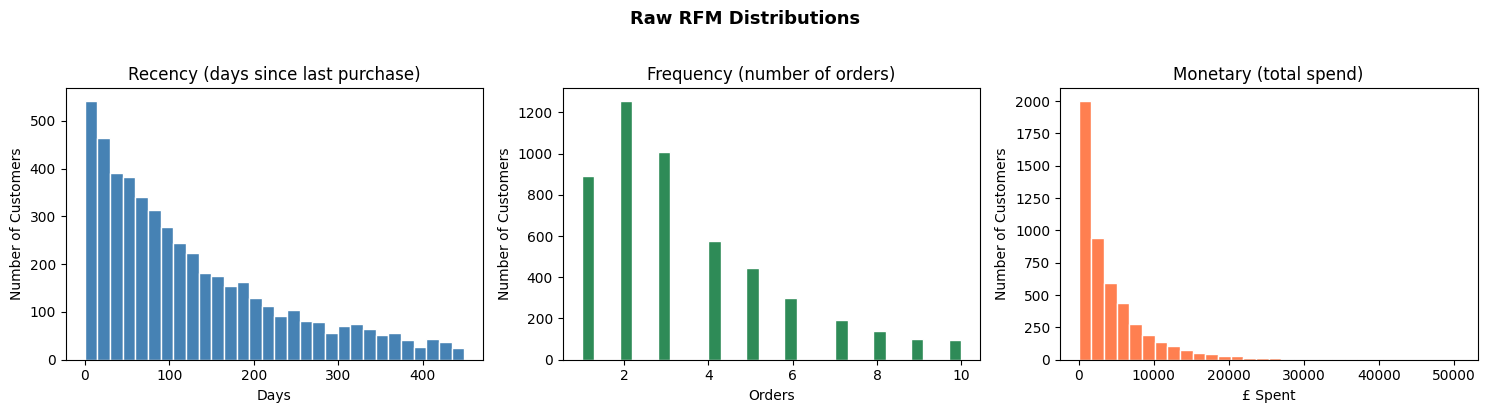

In [44]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rfm['Recency'],   bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Recency (days since last purchase)')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Number of Customers')

axes[1].hist(rfm['Frequency'], bins=30, color='seagreen',  edgecolor='white')
axes[1].set_title('Frequency (number of orders)')
axes[1].set_xlabel('Orders')
axes[1].set_ylabel('Number of Customers')

axes[2].hist(rfm['Monetary'],  bins=30, color='coral',     edgecolor='white')
axes[2].set_title('Monetary (total spend)')
axes[2].set_xlabel('₺ Spent')
axes[2].set_ylabel('Number of Customers')

plt.suptitle('Raw RFM Distributions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Figure 6:** Raw RFM distributions (Recency, Frequency, Monetary) across 5,000 customers. All three are right-skewed.

The raw RFM distributions are all right-skewed; a small number of customers have very high spend or frequency. After log transformation and standardization, distributions become approximately symmetric.

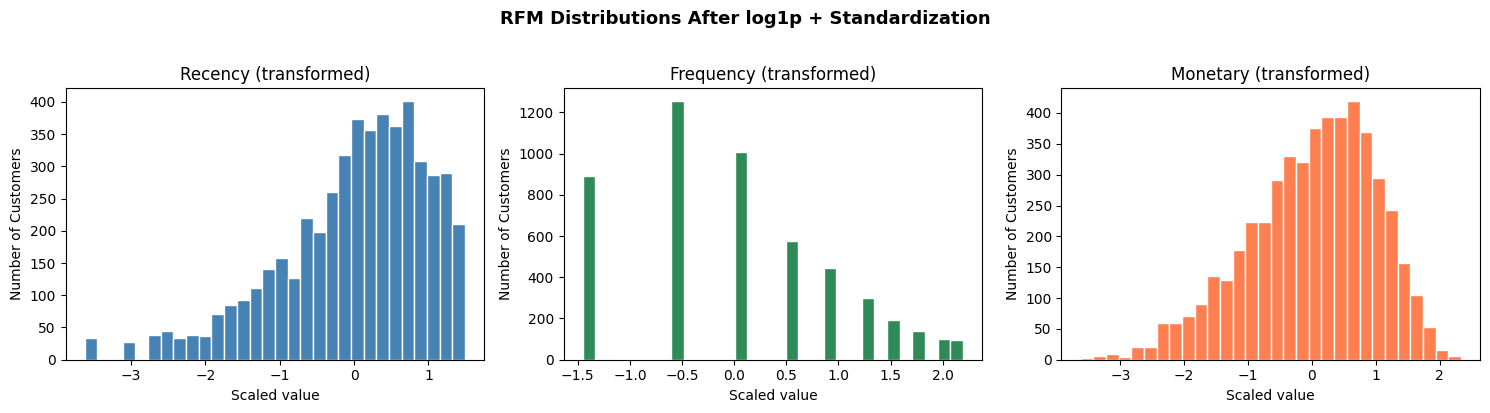

In [45]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Log-transform (log1p handles Recency = 0 safely)
rfm_log = rfm.copy()
rfm_log['Recency']   = np.log1p(rfm['Recency'])
rfm_log['Frequency'] = np.log1p(rfm['Frequency'])
rfm_log['Monetary']  = np.log1p(rfm['Monetary'])

# Standardize to mean=0, std=1
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[['Recency', 'Frequency', 'Monetary']])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rfm_scaled[:, 0], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Recency (transformed)')
axes[0].set_xlabel('Scaled value')
axes[0].set_ylabel('Number of Customers')

axes[1].hist(rfm_scaled[:, 1], bins=30, color='seagreen',  edgecolor='white')
axes[1].set_title('Frequency (transformed)')
axes[1].set_xlabel('Scaled value')
axes[1].set_ylabel('Number of Customers')

axes[2].hist(rfm_scaled[:, 2], bins=30, color='coral',     edgecolor='white')
axes[2].set_title('Monetary (transformed)')
axes[2].set_xlabel('Scaled value')
axes[2].set_ylabel('Number of Customers')

plt.suptitle('RFM Distributions After log1p + Standardization', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Figure 7:** RFM distributions after log1p transformation and standardization.

After log-transforming the data to reduce the skew, our distributions are approximately symmetric and ready for the K-Means model.

## 5. Results

### 5.1 Customer Segmentation (RFM + K-Means)

#### Choosing K — Elbow Method

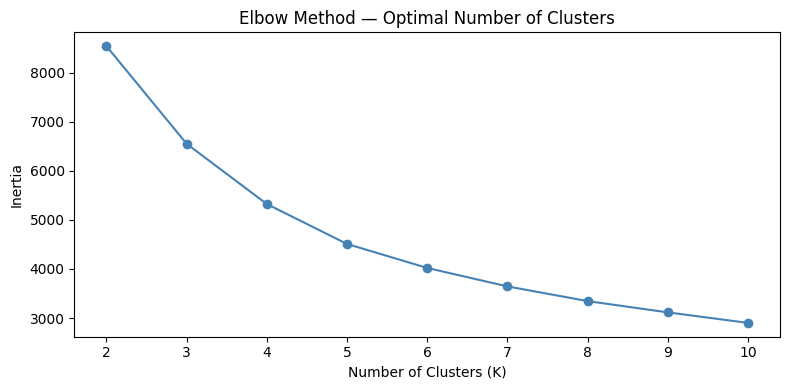

In [46]:
from sklearn.cluster import KMeans

inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

**Figure 8:** Elbow method plot showing inertia vs. number of clusters K. The curve flattens after K=4, supporting K=4 as the optimal choice.

Inertia drops sharply from K=2 to K=4, then flattens supporting K=4 as the optimal choice.

#### Fitting the Final Model (K=4)

In [ ]:
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)

cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

| Cluster | Avg Recency (days) | Avg Frequency | Avg Monetary (₺) |
|---|---|---|---|
| 0 | 12.49 | 4.08 | 4,866.98 |
| 1 | 202.39 | 1.44 | 473.17 |
| 2 | 155.73 | 2.63 | 3,633.03 |
| 3 | 69.69 | 6.18 | 9,056.59 |

**Figure 9:** K-Means cluster profiles — mean RFM values per cluster (K=4).

K-Means partitions all 5,000 customers into four groups by placing each customer into the 
cluster whose center (centroid) is closest to their RFM values. The table above shows the 
average Recency, Frequency, and Monetary value at the center of each cluster. Customers 
whose purchasing behavior most resembles these averages were assigned to that group.

Below we assign tites to these clusters that represent the type of customers within them and update the dataframe with a new segment column:

In [ ]:
segment_map = {3: 'Champions', 0: 'Loyal', 2: 'At Risk', 1: 'Inactive'}
rfm['Segment'] = rfm['Cluster'].map(segment_map)

print(rfm['Segment'].value_counts())

| Customer_ID | Recency | Frequency | Monetary (₺) | Cluster | Segment |
|---|---|---|---|---|---|
| CUST_00001 | 111 | 3 | 2,199.63 | 2 | At Risk |
| CUST_00002 | 283 | 2 | 809.90 | 1 | Inactive |
| CUST_00003 | 82 | 2 | 3,030.81 | 2 | At Risk |
| CUST_00004 | 41 | 1 | 383.22 | 1 | Inactive |
| CUST_00005 | 278 | 3 | 2,422.73 | 2 | At Risk |
| CUST_00006 | 211 | 3 | 1,245.83 | 2 | At Risk |
| CUST_00007 | 80 | 1 | 1,331.55 | 1 | Inactive |
| CUST_00008 | 168 | 3 | 5,602.29 | 2 | At Risk |
| CUST_00009 | 38 | 1 | 470.86 | 1 | Inactive |
| CUST_00010 | 21 | 3 | 1,421.16 | 0 | Loyal |

**Figure 10:** First 10 customers with cluster and segment labels assigned.

**Segment interpretations:**

| Segment | Avg. Recency | Avg. Frequency | Avg. Monetary | Description |
|---|---|---|---|---|
| Champions | 69.7 days | 6.2 orders | ₺9,057 | High spend, high frequency, recent. Best customers. |
| Loyal | 12.5 days | 4.1 orders | ₺4,867 | Very recently active, buy regularly. Prime to become Champions. |
| At Risk | 155.7 days | 2.6 orders | ₺3,633 | Decent spend history but disengaging. Target for re-engagement. |
| Inactive | 202.4 days | 1.4 orders | ₺473 | Low spend, low frequency, haven't bought in 6+ months. |

This answers Research Question 1: **yes, customers group into four distinct and interpretable behavioral types.**

**Figure 11:** Segment interpretation summary — average RFM values and behavioral description for each of the four customer segments.

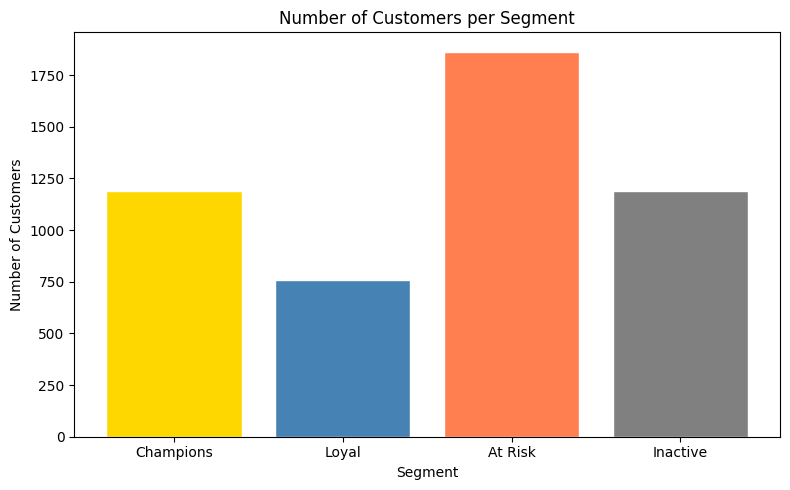

In [49]:
# Visualize segment counts
segment_order = ['Champions', 'Loyal', 'At Risk', 'Inactive']
colors = ['gold', 'steelblue', 'coral', 'grey']
counts = rfm['Segment'].value_counts().reindex(segment_order)

plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values, color=colors, edgecolor='white')
plt.title('Number of Customers per Segment')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

**Figure 12:** Bar chart showing the number of customers in each segment. At Risk is the largest group (1,864) and Loyal the smallest (757).

We see that the biggest segment of customers are "At Risk" (~1750), the smallest segment is "Loyal" (~750). This buissness should aim marketing strategies to target these "At Risk" customers and reduce churn.

### 5.2 Customer Lifetime Value Prediction

In [ ]:
clv_df = rfm.merge(numeric_agg, on='Customer_ID').merge(cat_agg, on='Customer_ID')
print(clv_df.shape)

| Customer_ID | Segment | Age | Avg Session (min) | Avg Pages | Avg Rating | Avg Delivery | Avg Discount (₺) | Returning? | Gender | Device | Payment | Product Category |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| CUST_00001 | At Risk | 40 | 14.33 | 9.00 | 3.33 | 9.33 | 46.02 | True | Male | Mobile | Credit Card | Books |
| CUST_00002 | Inactive | 33 | 15.00 | 10.00 | 4.00 | 5.00 | 35.53 | True | Male | Desktop | Credit Card | Beauty |
| CUST_00003 | At Risk | 42 | 10.50 | 8.50 | 3.50 | 6.00 | 0.00 | False | Male | Desktop | Credit Card | Home & Garden |
| CUST_00004 | Inactive | 53 | 16.00 | 15.00 | 5.00 | 4.00 | 97.78 | False | Male | Desktop | Credit Card | Fashion |
| CUST_00005 | At Risk | 32 | 12.67 | 9.33 | 3.67 | 5.67 | 0.00 | False | Male | Mobile | Credit Card | Fashion |

**Figure 13:** Combined customer-level feature table used for CLV regression (first 5 customers, selected columns).

We combine our three customer-level tables, rfm, numeric_agg, and cat_agg, into a single feature table to use in the CLV regression model.

#### Fitting the Regression Model for Customer Lifetime Value

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# One-hot encode categoricals
clv_encoded = pd.get_dummies(
    clv_df,
    columns=['Gender', 'Device_Type', 'Payment_Method', 'Product_Category'],
    drop_first=True
)

X = clv_encoded.drop(columns=['Customer_ID', 'Cluster', 'Segment', 'Monetary'])
y = np.log1p(clv_df['Monetary'])   # log-transform target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print(f"R² score: {r2_score(y_test, y_pred):.3f}")
print(f"MAE:      {mean_absolute_error(y_test, y_pred):.3f}")

R² score: 0.585
MAE:      0.676


The model explains ~59% of variation in log customer spend. This is a reasonable result for a linear model on behavioral data.

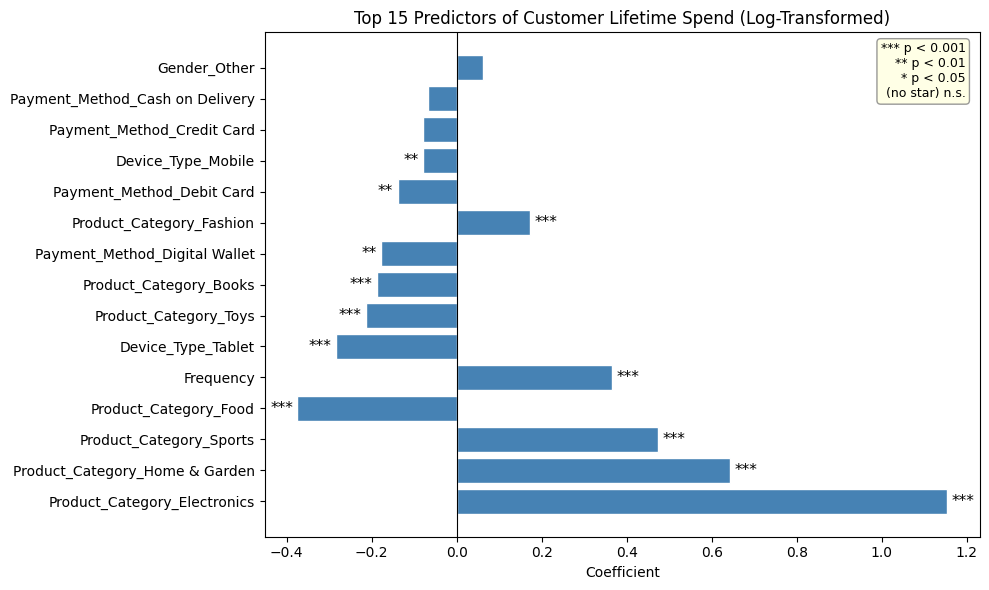

In [52]:
import statsmodels.api as sm

# Refit with statsmodels to get p-values
X_train_sm = sm.add_constant(X_train.astype(float))
sm_model   = sm.OLS(y_train.astype(float), X_train_sm).fit()

results_df = pd.DataFrame({
    'Feature':     X.columns,
    'Coefficient': sm_model.params[1:].values,
    'P_Value':     sm_model.pvalues[1:].values
})

def sig_stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return ''

results_df['Stars'] = results_df['P_Value'].apply(sig_stars)
top15 = results_df.sort_values('Coefficient', key=abs, ascending=False).head(15)

# Plot top 15 predictors
plt.figure(figsize=(10, 6))
bars = plt.barh(top15['Feature'], top15['Coefficient'], color='steelblue', edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Top 15 Predictors of Customer Lifetime Spend (Log-Transformed)')
plt.xlabel('Coefficient')

for bar, stars in zip(bars, top15['Stars']):
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    plt.text(x + 0.01 if x >= 0 else x - 0.01, y, stars,
             va='center', ha='left' if x >= 0 else 'right', fontsize=11)

legend_text = "*** p < 0.001\n** p < 0.01\n* p < 0.05\n(no star) n.s."
plt.gca().text(0.98, 0.98, legend_text, transform=plt.gca().transAxes,
               fontsize=9, va='top', ha='right',
               bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='grey', alpha=0.8))
plt.tight_layout()
plt.show()

**Figure 14:** Top 15 predictors of log-transformed customer lifetime spend (OLS coefficients). Stars indicate statistical significance: \*\*\* p<0.001, \*\* p<0.01, \* p<0.05.

The strongest positive predictors of lifetime spend are product categories like Electronics, Home & Garden, and Sports along with purchase Frequency.  Food is the strongest negative predictor, followed by Tablet device usage. Most payment method and device type effects are small and only marginally significant.

The dominance of Electronics, Home & Garden, and Sports makes intuitive sense, as these categories typically involve high-ticket purchases that drive total spend up significantly. Conversely, Food customers likely make frequent but low-value purchases, pulling their lifetime monetary value down relative to other categories.

#### Predicted CLV by Segment

To check the valitity of our K-means and Regression models, we look at the lifetime spending by customer segment.

| Segment | Avg. Predicted CLV (₺) |
|---|---|
| Champions | 9,742.30 |
| Loyal | 4,758.07 |
| At Risk | 2,516.04 |
| Inactive | 787.00 |

**Figure 15:** Average predicted customer lifetime value by segment.

In [ ]:
X_all = clv_encoded.drop(columns=['Customer_ID', 'Cluster', 'Segment', 'Monetary']).astype(float)
clv_encoded['Predicted_CLV'] = np.expm1(lr.predict(X_all))
rfm['Predicted_CLV'] = clv_encoded['Predicted_CLV'].values

segment_clv = rfm.groupby('Segment')['Predicted_CLV'].mean().reindex(segment_order).round(2)

plt.figure(figsize=(8, 5))
plt.bar(segment_order, segment_clv.values, color=colors, edgecolor='white')
plt.title('Average Predicted Customer Lifetime Value by Segment')
plt.xlabel('Segment')
plt.ylabel('Predicted Lifetime Spend (₺)')
plt.tight_layout()
plt.show()

**Figure 16:** Bar chart of average predicted customer lifetime value (₺) by segment. Champions show the highest spend and Inactive the lowest.

The predicted CLV values align closely with the RFM cluster profiles, validating both approaches. This confirms our answer to Research Question 2: **expensive product categories and order frequency are the strongest drivers of lifetime spend**, with Champions averaging ₺9,742 vs. ₺787 for Inactive customers.

### 5.3 Churn Prediction

#### Fitting the Regression Model for Churn Prediction

In [ ]:
rfm['Churned'] = (rfm['Recency'] >= 180).astype(int)

print("Churn counts:")
print(rfm['Churned'].value_counts())
print(f"\nOverall churn rate: {rfm['Churned'].mean():.1%}")

| Customer_ID | Recency | Frequency | Monetary (₺) | Segment | Predicted CLV (₺) | Churned |
|---|---|---|---|---|---|---|
| CUST_00001 | 111 | 3 | 2,199.63 | At Risk | 1,184.35 | 0 |
| CUST_00002 | 283 | 2 | 809.90 | Inactive | 895.05 | 1 |
| CUST_00003 | 82 | 2 | 3,030.81 | At Risk | 1,907.80 | 0 |
| CUST_00004 | 41 | 1 | 383.22 | Inactive | 1,076.35 | 0 |
| CUST_00005 | 278 | 3 | 2,422.73 | At Risk | 1,330.59 | 1 |

**Figure 17:** First 5 customers with churn label applied (Churned = 1 if Recency ≥ 180 days).

We add a new boolean variable to our dataframe, "Churned", that defines customers that have not ordered in 180 days or more as a churned customer.

#### Logistic Regression — Standard vs. Balanced

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import seaborn as sns

churn_df = clv_df.copy()
churn_df['Churned'] = rfm['Churned'].values

churn_encoded = pd.get_dummies(
    churn_df,
    columns=['Gender', 'Device_Type', 'Payment_Method', 'Product_Category'],
    drop_first=True
)

X_churn = churn_encoded.drop(
    columns=['Customer_ID', 'Cluster', 'Segment', 'Monetary', 'Churned', 'Recency', 'Frequency']
).astype(float)
y_churn = churn_encoded['Churned'].astype(float)

scaler_c = StandardScaler()
X_churn_scaled = scaler_c.fit_transform(X_churn)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_churn_scaled, y_churn, test_size=0.2, random_state=42
)

logit_standard = LogisticRegression(max_iter=1000, random_state=42)
logit_standard.fit(X_train_c, y_train_c)
y_pred_standard = logit_standard.predict(X_test_c)
cm = confusion_matrix(y_test_c, y_pred_standard)
tn, fp, fn, tp = cm.ravel()
print(f"Accuracy:    {(tp+tn)/len(y_test_c):.3f}")
print(f"Sensitivity: {tp/(tp+fn):.3f}")
print(f"Specificity: {tn/(tn+fp):.3f}")

Accuracy:    0.757
Sensitivity: 0.004
Specificity: 1.000


The standard model achieves 75.7% accuracy, but this is misleading because it reaches this by predicting 'not churned' for nearly every customer, resulting in a sensitivity of just 0.4%. For churn detection, this is essentially useless since correctly identifying at-risk customers is the goal.

In [57]:
logit_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
logit_balanced.fit(X_train_c, y_train_c)
y_pred_balanced = logit_balanced.predict(X_test_c)
cm = confusion_matrix(y_test_c, y_pred_balanced)
tn, fp, fn, tp = cm.ravel()
print(f"Accuracy:    {(tp+tn)/len(y_test_c):.3f}")
print(f"Sensitivity: {tp/(tp+fn):.3f}")
print(f"Specificity: {tn/(tn+fp):.3f}")

Accuracy:    0.534
Sensitivity: 0.516
Specificity: 0.540


To address this, we refit the model with class_weight='balanced', which penalizes misclassifying churned customers more heavily. This drops accuracy to 53.4%, but raises sensitivity to 51.6% which is a far more useful result for identifying customers at risk of churning. Missing a customer who is about to churn is more costly than accidentally targeting one who wasn't going to, hence why sensitivity matters more than overall accuracy here.

#### Logistic Regression Coefficients (Balanced Model)

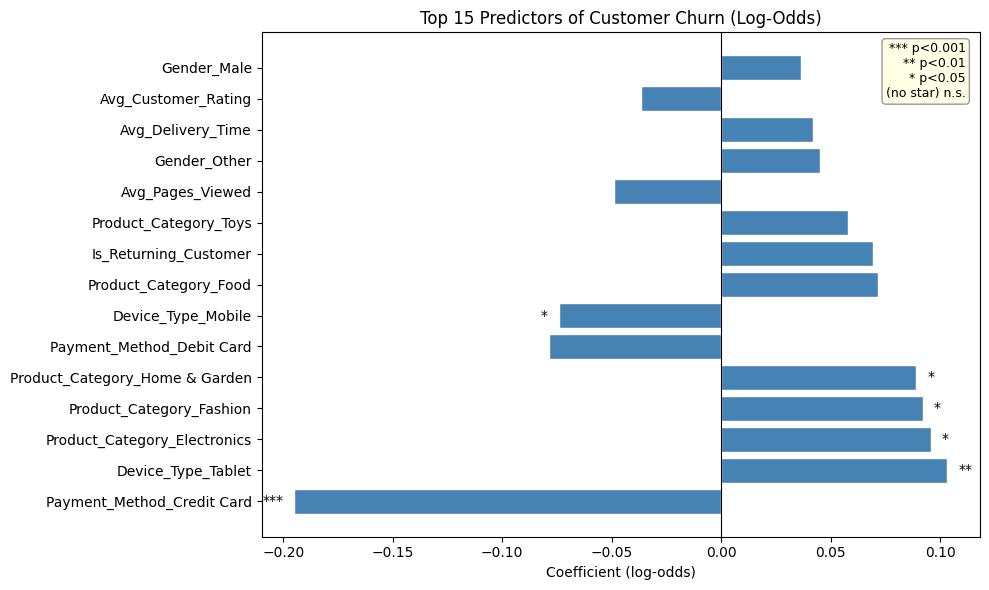

In [19]:
X_train_sm2 = sm.add_constant(pd.DataFrame(X_train_c, columns=X_churn.columns).astype(float))
logit_sm = sm.Logit(y_train_c.values, X_train_sm2).fit(method='bfgs', maxiter=500, disp=False)

coef_df = pd.DataFrame({
    'Feature':     X_churn.columns,
    'Coefficient': logit_sm.params[1:].values,
    'P_Value':     logit_sm.pvalues[1:].values
})
coef_df['Stars'] = coef_df['P_Value'].apply(sig_stars)
top15_churn = coef_df.sort_values('Coefficient', key=abs, ascending=False).head(15)

plt.figure(figsize=(10, 6))
bars = plt.barh(top15_churn['Feature'], top15_churn['Coefficient'], color='steelblue', edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Top 15 Predictors of Customer Churn (Log-Odds)')
plt.xlabel('Coefficient (log-odds)')

for bar, stars in zip(bars, top15_churn['Stars']):
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    plt.text(x + 0.005 if x >= 0 else x - 0.005, y, stars,
             va='center', ha='left' if x >= 0 else 'right', fontsize=10)

legend_text = "*** p<0.001\n** p<0.01\n* p<0.05\n(no star) n.s."
plt.gca().text(0.98, 0.98, legend_text, transform=plt.gca().transAxes,
               fontsize=9, va='top', ha='right',
               bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='grey', alpha=0.8))
plt.tight_layout()
plt.show()

**Figure 18:** Top 15 predictors of customer churn (logistic regression log-odds, balanced model). Stars indicate statistical significance: \*\*\* p<0.001, \*\* p<0.01, \* p<0.05.

Lower session engagement (fewer pages viewed, shorter session duration) is associated with higher churn risk. Notably, customers who pay by credit card show a strong negative association with churn, suggesting that the commitment of linking a card correlates with longer-term purchasing behavior. Similarly, mobile device users are less likely to churn, possibly reflecting habitual app-based shopping. This answers Research Question 3: **yes, customers likely to stop purchasing can be identified**.

## 6. Conclusion

### Findings

This project applied RFM clustering, OLS regression, and logistic regression to customer-level data from a simulated Turkish e-commerce platform. Despite limitations from synthetic data, the customer-level aggregation revealed genuine behavioral variation that supported meaningful modeling.

**By research question:**

1. **Can customers be grouped into meaningful types?** Yes. K-Means with K=4 produced four well-separated, interpretable segments, Champions, Loyal, At Risk, and Inactive, that differ clearly in recency, frequency, spend, and churn rates.

2. **What drives higher lifetime spending?** Purchase frequency and product category are the strongest predictors. Electronics, Home & Garden, and Sports customers spend significantly more due to the high-price nature of those purchases, while Food customers show the opposite effect. The CLV regression (R² = 0.585) confirms these patterns, and predicted spend aligns closely with the unsupervised cluster structure, with Champions averaging ₺9,742 vs. ₺787 for Inactive customers.

3. **Can we identify customers likely to churn?** The standard logistic regression is essentially useless for this task, but the balanced model improves sensitivity to 51.6%, identifying roughly half of at-risk customers, a meaningful result for targeted advertisment. Credit card users and mobile shoppers show lower churn risk, while lower session engagement is the strongest behavioral signal of impending churn.

### Business Implications

- **Champions** should be retained with loyalty rewards or early product access.
- **Loyal** customers are the best candidates to move into the Champions segment with targeted incentives.
- **At Risk** customers warrant a re-engagement campaign before they become Inactive.
- **Inactive** customers have low conversion potential and should receive minimal marketing spend.

From the CLV model, the business should prioritize acquiring and retaining Electronics, Home & Garden, and Sports customers, as these categories are the strongest drivers of lifetime spend.

From the churn model, the business should pay particular attention to customers showing declining session engagement (fewer pages viewed and shorter browsing sessions) is a warning signs of churn. Encouraging credit card linking and mobile app adoption may also help reduce churn, as both are associated with lower dropout rates.

### Limitations

The synthetic nature of the data is the primary limitation i.e. patterns may not reflect real consumer behavior. Additionally, the 180-day churn threshold is an assumption; different cutoffs would produce different results.

### Future Work
Based on our results some natural follow-up questions emerge:

- What distinguishes the At Risk customers who eventually recover vs. those who become Inactive? Are there early warning signs that separate them?
- The CLV model explained ~59% of spending variation, meaning 41% is unexplained. What other factors might account for this? Seasonal purchasing patterns, promotional responses, or life events?
- Given that product category was such a dominant CLV predictor, it would be interesting to ask whether a customer's first purchase category is predictive of their long-term spending trajectory.
- We defined churn as 180+ days of inactivity, but this is arbitrary. How sensitive are churn model results to different cutoff choices (say 90 days or 365 days)?
- The model only identifies customers who have already effectively churned. Could we build an earlier warning system that flags customers showing declining engagement before they hit the 180-day threshold?

## 7. References

Tuygur, U. (2024). E-commerce customer behavior and sales analysis [Dataset]. Kaggle. https://www.kaggle.com/datasets/umuttuygurr/e-commerce-customer-behavior-and-sales-analysis-tr

IBM. (n.d.). What is k-means clustering? IBM Think. https://www.ibm.com/think/topics/k-means-clustering

Gusarova, M. (2023, February 5). How to improve logistic regression in imbalanced data with class weights. Medium. https://medium.com/@data.science.enthusiast/how-to-improve-logistic-regression-in-imbalanced-data-with-class-weights-1693719136aa

## 8. Code Appendix

Shape: (17049, 18)

Data types:
Order_ID                        str
Customer_ID                     str
Date                            str
Age                           int64
Gender                          str
City                            str
Product_Category                str
Unit_Price                  float64
Quantity                      int64
Discount_Amount             float64
Total_Amount                float64
Payment_Method                  str
Device_Type                     str
Session_Duration_Minutes      int64
Pages_Viewed                  int64
Is_Returning_Customer          bool
Delivery_Time_Days            int64
Customer_Rating               int64
dtype: object
Date range: 2023-01-01 00:00:00 to 2024-03-25 00:00:00
Customers: 5000
RFM shape: (5000, 4)


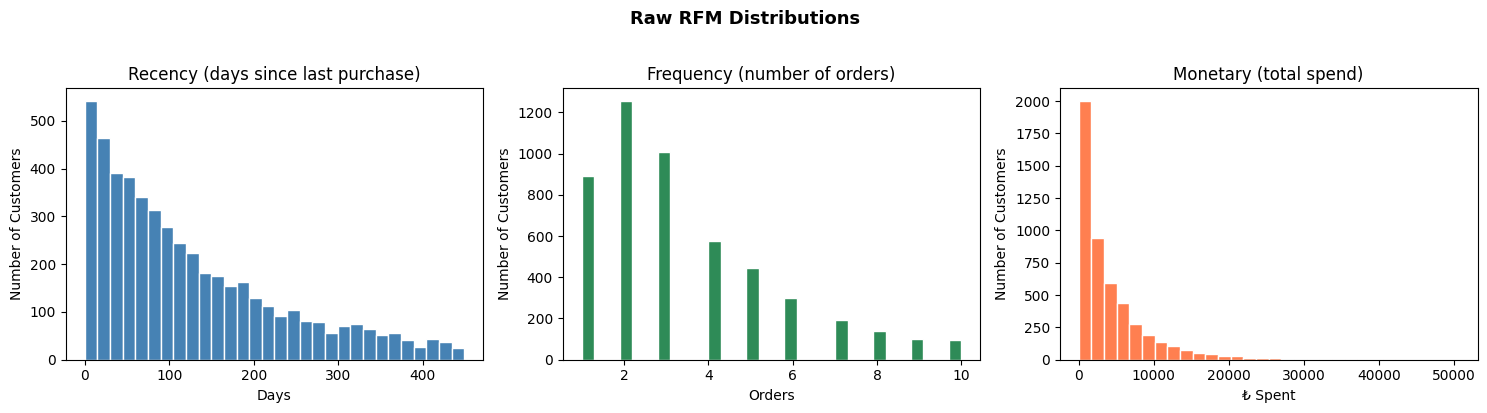

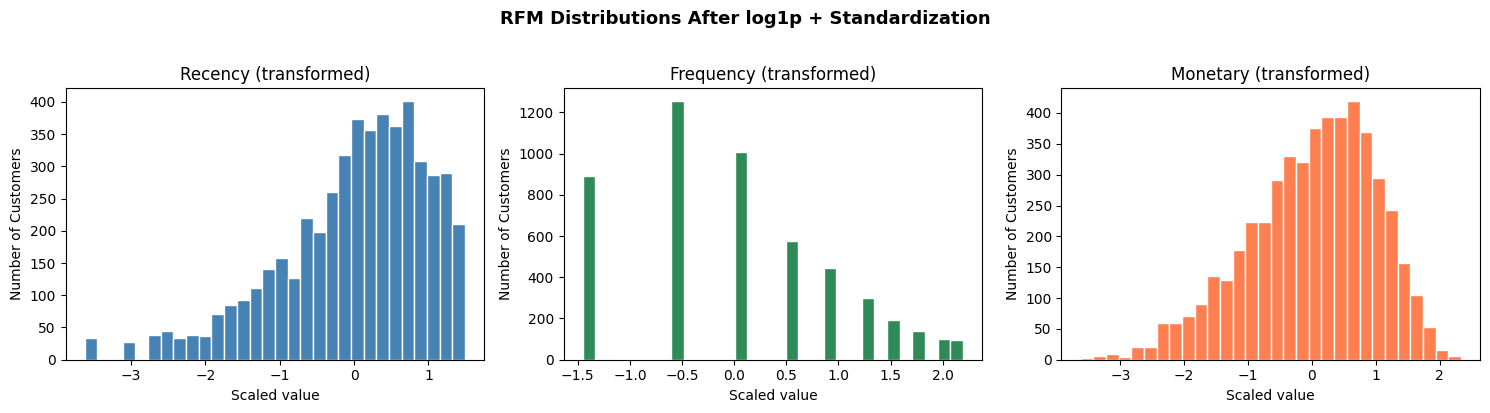

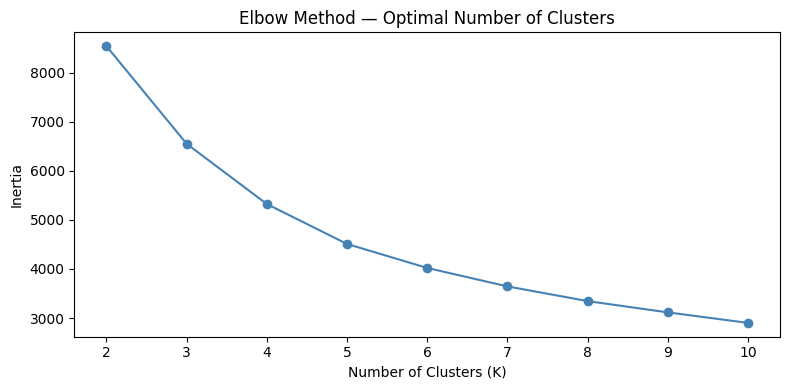

Segment
At Risk      1864
Inactive     1191
Champions    1188
Loyal         757
Name: count, dtype: int64


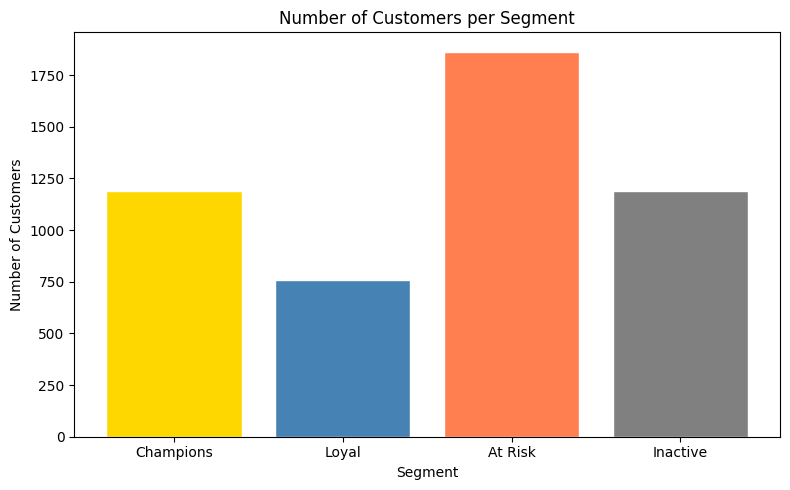

(5000, 17)
R² score: 0.585
MAE:      0.676


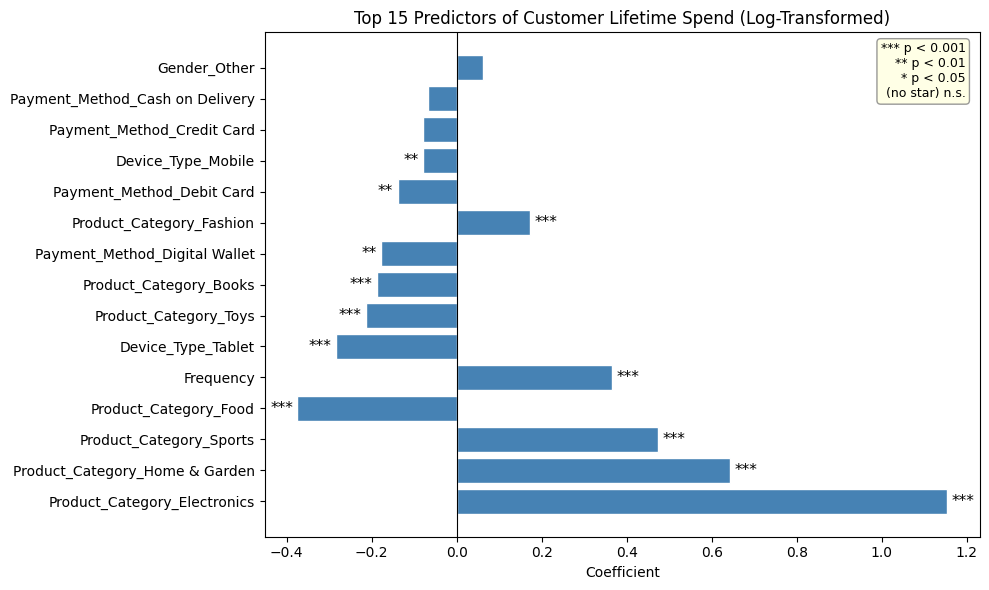

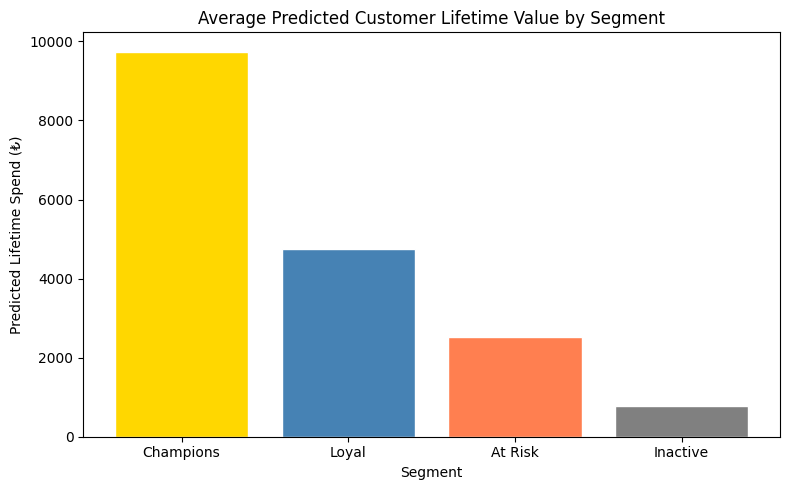

Churn counts:
Churned
0    3692
1    1308
Name: count, dtype: int64

Overall churn rate: 26.2%
Accuracy:    0.757
Sensitivity: 0.004
Specificity: 1.000
Accuracy:    0.534
Sensitivity: 0.516
Specificity: 0.540


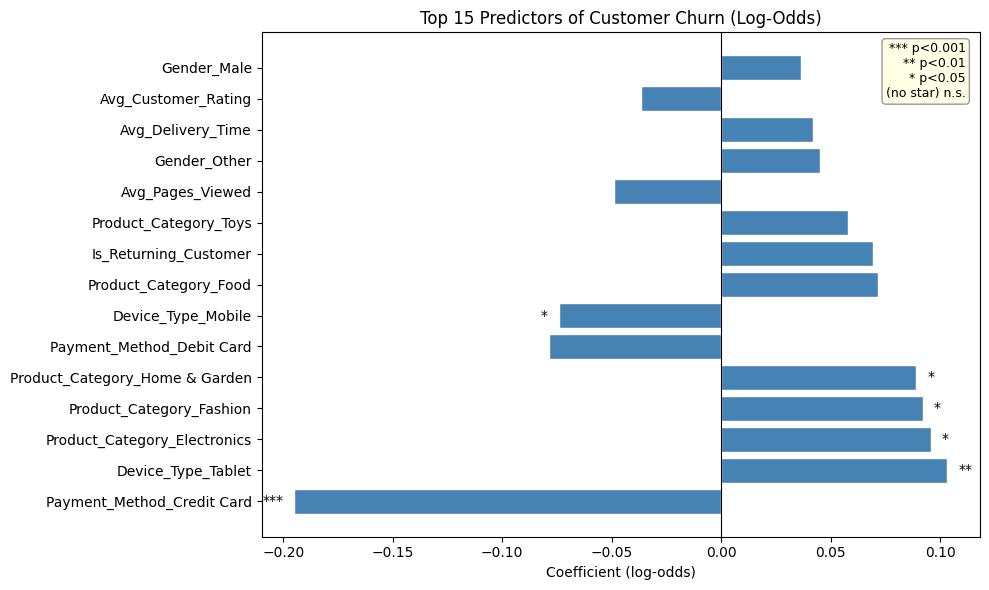

In [1]:
# ── Package Imports ───────────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import kagglehub
from scipy.stats import mode
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, confusion_matrix

# ── Data Loading ──────────────────────────────────────────────────────────────
path = kagglehub.dataset_download(
    "umuttuygurr/e-commerce-customer-behavior-and-sales-analysis-tr"
)
csv_file = "ecommerce_customer_behavior_dataset_v2.csv"
df = pd.read_csv(os.path.join(path, csv_file))
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

# ── Missingness and Duplicates ────────────────────────────────────────────────
missing = df.isnull().sum()
duplicate_count = df.duplicated().sum()

# ── Type Correction ───────────────────────────────────────────────────────────
df['Date'] = pd.to_datetime(df['Date'])
print("Date range:", df['Date'].min(), "to", df['Date'].max())

# ── Restructuring: Transaction → Customer Level ───────────────────────────────
numeric_agg = df.groupby('Customer_ID').agg(
    Age                  = ('Age',                      'first'),
    Avg_Session_Duration = ('Session_Duration_Minutes', 'mean'),
    Avg_Pages_Viewed     = ('Pages_Viewed',             'mean'),
    Avg_Customer_Rating  = ('Customer_Rating',          'mean'),
    Avg_Delivery_Time    = ('Delivery_Time_Days',       'mean'),
    Avg_Discount         = ('Discount_Amount',          'mean'),
    Is_Returning_Customer= ('Is_Returning_Customer',    'first')
).reset_index()

cat_agg = df.groupby('Customer_ID').agg(
    Gender           = ('Gender',           lambda x: x.mode()[0]),
    Device_Type      = ('Device_Type',      lambda x: x.mode()[0]),
    Payment_Method   = ('Payment_Method',   lambda x: x.mode()[0]),
    Product_Category = ('Product_Category', lambda x: x.mode()[0])
).reset_index()

print(f"Customers: {numeric_agg.shape[0]}")

# ── RFM Computation ───────────────────────────────────────────────────────────
snapshot_date = df['Date'].max()

rfm = df.groupby('Customer_ID').agg(
    Recency  = ('Date',     lambda x: (snapshot_date - x.max()).days),
    Frequency= ('Order_ID', 'nunique'),
    Monetary = ('Total_Amount', 'sum')
).reset_index()

print("RFM shape:", rfm.shape)

# ── RFM Distributions ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(rfm['Recency'],   bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Recency (days since last purchase)')
axes[0].set_xlabel('Days'); axes[0].set_ylabel('Number of Customers')
axes[1].hist(rfm['Frequency'], bins=30, color='seagreen',  edgecolor='white')
axes[1].set_title('Frequency (number of orders)')
axes[1].set_xlabel('Orders'); axes[1].set_ylabel('Number of Customers')
axes[2].hist(rfm['Monetary'],  bins=30, color='coral',     edgecolor='white')
axes[2].set_title('Monetary (total spend)')
axes[2].set_xlabel('₺ Spent'); axes[2].set_ylabel('Number of Customers')
plt.suptitle('Raw RFM Distributions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# ── Log Transform + Standardize ───────────────────────────────────────────────
rfm_log = rfm.copy()
rfm_log['Recency']   = np.log1p(rfm['Recency'])
rfm_log['Frequency'] = np.log1p(rfm['Frequency'])
rfm_log['Monetary']  = np.log1p(rfm['Monetary'])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(
    rfm_log[['Recency', 'Frequency', 'Monetary']]
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(rfm_scaled[:, 0], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Recency (transformed)')
axes[0].set_xlabel('Scaled value'); axes[0].set_ylabel('Number of Customers')
axes[1].hist(rfm_scaled[:, 1], bins=30, color='seagreen',  edgecolor='white')
axes[1].set_title('Frequency (transformed)')
axes[1].set_xlabel('Scaled value'); axes[1].set_ylabel('Number of Customers')
axes[2].hist(rfm_scaled[:, 2], bins=30, color='coral',     edgecolor='white')
axes[2].set_title('Monetary (transformed)')
axes[2].set_xlabel('Scaled value'); axes[2].set_ylabel('Number of Customers')
plt.suptitle('RFM Distributions After log1p + Standardization',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# ── Elbow Method ──────────────────────────────────────────────────────────────
inertia = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)'); plt.ylabel('Inertia')
plt.xticks(k_range); plt.tight_layout(); plt.show()

# ── K-Means (K=4) ─────────────────────────────────────────────────────────────
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency',
                                          'Monetary']].mean().round(2)

# ── Segment Labels ────────────────────────────────────────────────────────────
segment_map = {3: 'Champions', 0: 'Loyal', 2: 'At Risk', 1: 'Inactive'}
rfm['Segment'] = rfm['Cluster'].map(segment_map)
print(rfm['Segment'].value_counts())

# ── Segment Bar Chart ─────────────────────────────────────────────────────────
segment_order = ['Champions', 'Loyal', 'At Risk', 'Inactive']
colors = ['gold', 'steelblue', 'coral', 'grey']
counts = rfm['Segment'].value_counts().reindex(segment_order)

plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values, color=colors, edgecolor='white')
plt.title('Number of Customers per Segment')
plt.xlabel('Segment'); plt.ylabel('Number of Customers')
plt.tight_layout(); plt.show()

# ── Build CLV Feature Table ───────────────────────────────────────────────────
clv_df = (rfm.merge(numeric_agg, on='Customer_ID')
          .merge(cat_agg, on='Customer_ID'))
print(clv_df.shape)

# ── OLS Regression — CLV Prediction ──────────────────────────────────────────
clv_encoded = pd.get_dummies(
    clv_df,
    columns=['Gender', 'Device_Type', 'Payment_Method', 'Product_Category'],
    drop_first=True
)

X = clv_encoded.drop(columns=['Customer_ID', 'Cluster', 'Segment', 'Monetary'])
y = np.log1p(clv_df['Monetary'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print(f"R² score: {r2_score(y_test, y_pred):.3f}")
print(f"MAE:      {mean_absolute_error(y_test, y_pred):.3f}")

# ── OLS Coefficient Plot ──────────────────────────────────────────────────────
X_train_sm = sm.add_constant(X_train.astype(float))
sm_model   = sm.OLS(y_train.astype(float), X_train_sm).fit()

results_df = pd.DataFrame({
    'Feature':     X.columns,
    'Coefficient': sm_model.params[1:].values,
    'P_Value':     sm_model.pvalues[1:].values
})

def sig_stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return ''

results_df['Stars'] = results_df['P_Value'].apply(sig_stars)
top15 = results_df.sort_values(
    'Coefficient', key=abs, ascending=False
).head(15)

plt.figure(figsize=(10, 6))
bars = plt.barh(
    top15['Feature'], top15['Coefficient'],
    color='steelblue', edgecolor='white'
)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Top 15 Predictors of Customer Lifetime Spend (Log-Transformed)')
plt.xlabel('Coefficient')
for bar, stars in zip(bars, top15['Stars']):
    x = bar.get_width(); y = bar.get_y() + bar.get_height() / 2
    plt.text(x + 0.01 if x >= 0 else x - 0.01, y, stars,
             va='center', ha='left' if x >= 0 else 'right', fontsize=11)
legend_text = "*** p < 0.001\n** p < 0.01\n* p < 0.05\n(no star) n.s."
plt.gca().text(0.98, 0.98, legend_text, transform=plt.gca().transAxes,
               fontsize=9, va='top', ha='right',
               bbox=dict(boxstyle='round', facecolor='lightyellow', 
                         edgecolor='grey', alpha=0.8))
plt.tight_layout(); plt.show()

# ── Predicted CLV by Segment ──────────────────────────────────────────────────
X_all = clv_encoded.drop(
    columns=['Customer_ID', 'Cluster', 'Segment', 'Monetary']
).astype(float)
clv_encoded['Predicted_CLV'] = np.expm1(lr.predict(X_all))
rfm['Predicted_CLV'] = clv_encoded['Predicted_CLV'].values

segment_clv = (
    rfm.groupby('Segment')['Predicted_CLV']
    .mean().reindex(segment_order).round(2)
)

plt.figure(figsize=(8, 5))
plt.bar(segment_order, segment_clv.values, color=colors, edgecolor='white')
plt.title('Average Predicted Customer Lifetime Value by Segment')
plt.xlabel('Segment'); plt.ylabel('Predicted Lifetime Spend (₺)')
plt.tight_layout(); plt.show()

# ── Define Churn ──────────────────────────────────────────────────────────────
rfm['Churned'] = (rfm['Recency'] >= 180).astype(int)
print("Churn counts:")
print(rfm['Churned'].value_counts())
print(f"\nOverall churn rate: {rfm['Churned'].mean():.1%}")

# ── Logistic Regression — Standard ───────────────────────────────────────────
churn_df = clv_df.copy()
churn_df['Churned'] = rfm['Churned'].values

churn_encoded = pd.get_dummies(
    churn_df,
    columns=['Gender', 'Device_Type', 'Payment_Method', 'Product_Category'],
    drop_first=True
)

X_churn = churn_encoded.drop(
    columns=['Customer_ID', 'Cluster', 'Segment', 'Monetary', 'Churned',
             'Recency', 'Frequency']
).astype(float)
y_churn = churn_encoded['Churned'].astype(float)

scaler_c = StandardScaler()
X_churn_scaled = scaler_c.fit_transform(X_churn)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_churn_scaled, y_churn, test_size=0.2, random_state=42
)

logit_standard = LogisticRegression(max_iter=1000, random_state=42)
logit_standard.fit(X_train_c, y_train_c)
y_pred_standard = logit_standard.predict(X_test_c)
cm = confusion_matrix(y_test_c, y_pred_standard)
tn, fp, fn, tp = cm.ravel()
print(f"Accuracy:    {(tp+tn)/len(y_test_c):.3f}")
print(f"Sensitivity: {tp/(tp+fn):.3f}")
print(f"Specificity: {tn/(tn+fp):.3f}")

# ── Logistic Regression — Balanced ────────────────────────────────────────────
logit_balanced = LogisticRegression(max_iter=1000, random_state=42, 
                                    class_weight='balanced')
logit_balanced.fit(X_train_c, y_train_c)
y_pred_balanced = logit_balanced.predict(X_test_c)
cm = confusion_matrix(y_test_c, y_pred_balanced)
tn, fp, fn, tp = cm.ravel()
print(f"Accuracy:    {(tp+tn)/len(y_test_c):.3f}")
print(f"Sensitivity: {tp/(tp+fn):.3f}")
print(f"Specificity: {tn/(tn+fp):.3f}")

# ── Churn Coefficient Plot ────────────────────────────────────────────────────
X_train_sm2 = sm.add_constant(
    pd.DataFrame(X_train_c, columns=X_churn.columns)
    .astype(float)
)
logit_sm = sm.Logit(y_train_c.values, X_train_sm2).fit(method='bfgs', 
                                                       maxiter=500, disp=False)

coef_df = pd.DataFrame({
    'Feature':     X_churn.columns,
    'Coefficient': logit_sm.params[1:].values,
    'P_Value':     logit_sm.pvalues[1:].values
})
coef_df['Stars'] = coef_df['P_Value'].apply(sig_stars)
top15_churn = coef_df.sort_values('Coefficient', key=abs, 
                                  ascending=False).head(15)

plt.figure(figsize=(10, 6))
bars = plt.barh(top15_churn['Feature'], top15_churn['Coefficient'], 
                color='steelblue', edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Top 15 Predictors of Customer Churn (Log-Odds)')
plt.xlabel('Coefficient (log-odds)')
for bar, stars in zip(bars, top15_churn['Stars']):
    x = bar.get_width(); y = bar.get_y() + bar.get_height() / 2
    plt.text(x + 0.005 if x >= 0 else x - 0.005, y, stars,
             va='center', ha='left' if x >= 0 else 'right', fontsize=10)
legend_text = "*** p<0.001\n** p<0.01\n* p<0.05\n(no star) n.s."
plt.gca().text(0.98, 0.98, legend_text, transform=plt.gca().transAxes,
               fontsize=9, va='top', ha='right',
               bbox=dict(boxstyle='round', facecolor='lightyellow',
                         edgecolor='grey', alpha=0.8))
plt.tight_layout(); plt.show()